In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm

from nystroem_ksd.ksd import get_sns_conf

In [2]:
plt.rcParams.update({
    'text.latex.preamble': r'\usepackage{amsfonts}\usepackage{bm}'
})

In [3]:
df = pd.read_csv("../results/infinite-dim-ksd.csv", index_col=0)

df = df.replace("KSD_SE_T2_qt","KSD").replace("KSD_SE_T2_nys", "N-KSD")

In [4]:
algorithms = ["N-KSD", "KSD"]
labels = algorithms
sns_conf = get_sns_conf(algorithms=algorithms)

df = df.sort_values("test")

In [5]:
df.head()

,n,data,test,rejects,time
0,50,Ex1,KSD,0.034,17.324734
0,200,Ex2,KSD,1.000,66.212375
0,200,Ex1,KSD,0.050,47.493662
0,100,Ex5,KSD,0.972,15.723288
0,200,Ex5,KSD,1.000,48.175709


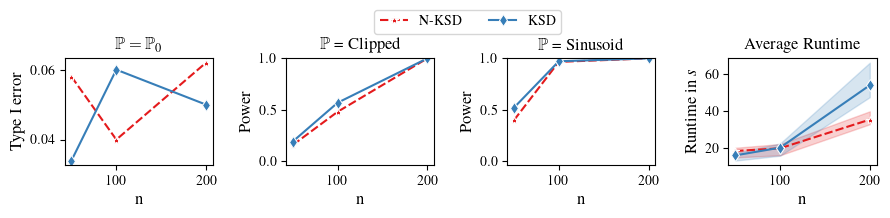

In [21]:
fig, (ax1,ax2,ax3,ax4) = plt.subplots(1,4,figsize=(9,2))

sns.lineplot(data=df[df["data"] == "Ex1"], x="n", y="rejects", hue="test", ax=ax1, style="test", **sns_conf)
sns.lineplot(data=df[df["data"] == "Ex2"], x="n", y="rejects", hue="test", ax=ax2, style="test", **sns_conf)
sns.lineplot(data=df[df["data"] == "Ex5"], x="n", y="rejects", hue="test", ax=ax3, style="test", **sns_conf)
sns.lineplot(data=df, x="n", y="time", hue="test", ax=ax4, style="test", **sns_conf)

Line, Label = ax1.get_legend_handles_labels()
for ax in [ax1,ax2,ax3,ax4]:
    ax.get_legend().remove()
    ax.set_xlabel("n")


fig.legend(Line, Label, loc="upper center", bbox_to_anchor=(0.525, 1.1), ncol=3)
ax2.set_ylim((np.float64(-0.04266666666666667), np.float64(1.006)))
ax3.set_ylim((np.float64(-0.04266666666666667), np.float64(1.006)))
ax1.set_ylabel("Type I error")
ax2.set_ylabel("Power")
ax3.set_ylabel("Power")
ax4.set_ylabel("Runtime in $s$")


ax1.set_title("$\\mathbb {P} = \\mathbb {P}_0$")
ax2.set_title("$\\mathbb {P}$ = Clipped")
ax3.set_title("$\\mathbb {P}$ = Sinusoid")
ax4.set_title("Average Runtime")

plt.tight_layout()
plt.savefig("../../figures/infinite-dim-ksd.pdf", bbox_inches=None, pad_inches=0)
plt.show()

In [6]:
d2


,n,data,test,rejects,time
0,50,VonMises,KSD,0.33,2.850383
0,200,Uniform,KSD,0.01,20.539018
0,100,VonMises,KSD,0.81,6.608052
0,100,Uniform,KSD,0.03,6.228400
0,50,Uniform,KSD,0.01,2.606023
0,200,VonMises,KSD,0.98,31.091336
0,30,VonMises,KSD,0.18,1.871727
0,30,Uniform,KSD,0.02,1.922354
0,50,Uniform,N-KSD,0.03,2.199688
0,30,VonMises,N-KSD,0.20,2.167592
